In [1]:
import yfinance as yf

symbols = ['NVDA', 'META', 'AMZN','AAPL', 'GOOGL']

for symbol in symbols:
    stock = yf.Ticker(symbol)
    price = stock.info.get('currentPrice', 'N/A')
    print(f"{symbol}: ${price}")




NVDA: $182.48
META: $653.56
AMZN: $208.39
AAPL: $264.72
GOOGL: $306.52


In [2]:
from dotenv import load_dotenv
import os

# load .env from the notebook working directory
load_dotenv()
# check if the environment variable is loaded

True

In [3]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("google_genai:gemini-2.5-flash")
response = llm.invoke("What is the capital of France?")

In [19]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated, Any
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition

class StockAgentState(TypedDict):
    messages: Annotated[list, add_messages]
    

In [5]:
@tool
def get_current_stock_price(symbol: str) -> float:
    
    '''
    Returns the current stock price for the given symbol.
    symbol: The stock ticker symbol (e.g., 'AAPL' for Apple Inc.)
    return: Current stock price as a string. If the price is not available, returns 'N/A'.

    '''

    stock = yf.Ticker(symbol)
    price = stock.info.get('currentPrice', 'N/A')

    return price

@tool
def get_stock_info_time_period(symbol: str, period: str) -> str:

    '''
        Returns historical stock data for the given symbol and time period.
        period can be one of the following: '1d', '5d', '1mo', '3mo', '6mo', '1y', '2y', '5y', '10y', 'ytd', 'max'
    '''
    stock = yf.Ticker(symbol)
    hist = stock.history(period=period)
    if hist.empty:
        return f"No historical data available for {symbol} with period {period}."
    else:
        return f"Historical data for {symbol} over the last {period}:\n{hist}"


In [7]:
tools = [get_current_stock_price, get_stock_info_time_period]
llm_with_tools = llm.bind_tools(tools)

In [8]:
def chatbot_response(state: StockAgentState) -> StockAgentState:
    # Get the last user message
    return {"messages": llm_with_tools.invoke(state["messages"])}

In [10]:
graph_builder = StateGraph(StockAgentState)

graph_builder.add_node("chatbot_response", chatbot_response)
graph_builder.add_node("tools", ToolNode(tools))
    
graph_builder.add_edge(START, "chatbot_response")
graph_builder.add_conditional_edges("chatbot_response", tools_condition)
graph_builder.add_edge("tools", "chatbot_response")
graph_builder.add_edge("chatbot_response", END)


In [11]:
graph = graph_builder.compile()

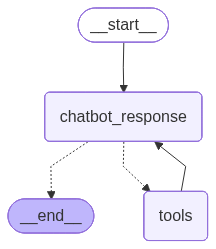

In [12]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))


In [21]:
def extract_text_content(content: Any) -> str:
    # Case 1: already plain string
    if isinstance(content, str):
        return content

    # Case 2: list of blocks like [{'type':'text','text':'...','extras':{...}}, ...]
    if isinstance(content, list):
        parts = []
        for block in content:
            if isinstance(block, dict) and block.get("type") == "text" and "text" in block:
                parts.append(block["text"])
        if parts:
            return "\n".join(parts)

    # Fallback: stringify
    return str(content)

In [22]:
prompt = [{"role": "user", "content": "What is the stock price of NVDA ? what will be the total cost for 10 shares?"}]
response = graph.invoke({"messages": prompt})
last_content = response["messages"][-1].content
print("Chatbot response:", extract_text_content(last_content))

Chatbot response: The current stock price of NVDA is 182.48. The total cost for 10 shares would be 1824.8.


In [23]:
## Create a new conversation with multiple messages in the history
state = None
while True:
    user_input = input("User: ")
    if user_input.lower() == "exit":
        break

    if state is None:
        state = {"messages": [{"role": "user", "content": user_input}]}

    state["messages"].append({"role": "user", "content": user_input})
    state = graph.invoke(state)
    # The graph may return langchain message objects (e.g. AIMessage) which are not subscriptable.
    last = state["messages"][-1]
    if hasattr(last, 'content'):
        content = last.content
    elif isinstance(last, dict):
        content = last.get("content")
    else:
        content = str(last)
    print("Chatbot response:", extract_text_content(content))

Chatbot response: The current stock price of AMZN is 208.39.
Chatbot response: The current stock price of NVIDIA is 182.48. The total price for 10 shares would be 182.48 * 10 = 1824.8.
Chatbot response: Here is the historical data for AMZN over the last 5 days:

Date (2026-02-24): Open: 205.47, High: 210.36, Low: 203.25, Close: 208.559998, Volume: 41137200
Date (2026-02-25): Open: 210.460007, High: 211.589996, Low: 208.929993, Close: 210.639999, Volume: 41346400
Date (2026-02-26): Open: 210.729996, High: 211.050003, Low: 205.350006, Close: 207.919998, Volume: 47756800
Date (2026-02-27): Open: 206.830002, High: 210.330002, Low: 205.199997, Close: 210.000000, Volume: 57422800
Date (2026-03-02): Open: 204.550003, High: 209.729996, Low: 203.460007, Close: 208.389999, Volume: 45915800
Chatbot response: Here is the historical data for AAPL over the last 5 days:

Date (2026-02-24): Open: 267.859985, High: 274.890015, Low: 267.709991, Close: 272.140015, Volume: 47014600
Date (2026-02-25): Open